# Customizing the Benchmark Trustworthiness Index

The BTI's weights are defaults, not dogma. This notebook recomputes the index under custom weights and shows the one thing no re-weighting can do: rescue a dataset whose label ships its own answer key.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd() if (Path.cwd() / 'datasets').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))
import pandas as pd
from synthaudit import Audit
from synthaudit import scoring
df = pd.read_csv(ROOT / 'datasets' / 'grid_stability.csv')
audit = Audit(df, target='stabf', name='grid')
results = audit.run(verbose=False)
results['scoring']['pillars']

{'L': 0.0, 'F': 0.8462, 'H': 1.0, 'R': 0.7179, 'I': 1.0}

In [2]:
custom = scoring.run(
    df, results['profile'], results['identity'], results['determinism'],
    results['leakage'], results['taxonomy'], 'stabf',
    weights={'L': 0.10, 'F': 0.30, 'H': 0.20, 'R': 0.20, 'I': 0.20},
)
print('default:', results['scoring']['bti'], results['scoring']['grade'])
print('custom :', custom['bti'], custom['grade'])

default: 0.2312 F
custom : 0.5616 C


Even after slashing the label-integrity weight to 0.10, the floored pillar caps the index (the non-compensation property, proved in the paper). Sweep the weight to see the ceiling:

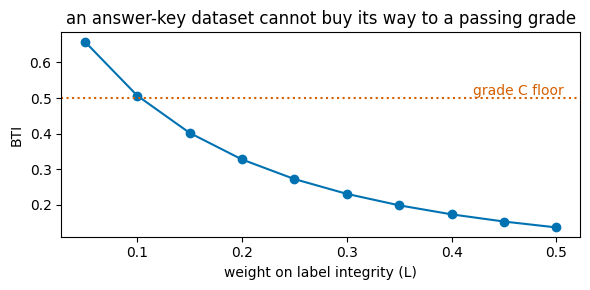

In [3]:
import numpy as np
import matplotlib.pyplot as plt
ws, btis = np.linspace(0.05, 0.5, 10), []
for w in ws:
    s = scoring.run(df, results['profile'], results['identity'],
                    results['determinism'], results['leakage'],
                    results['taxonomy'], 'stabf',
                    weights={'L': float(w), 'F': .2, 'H': .2, 'R': .15, 'I': .15})
    btis.append(s['bti'])
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(ws, btis, marker='o', color='#0072B2')
ax.axhline(0.5, ls=':', c='#D55E00'); ax.text(0.42, 0.51, 'grade C floor', color='#D55E00')
ax.set_xlabel('weight on label integrity (L)'); ax.set_ylabel('BTI')
ax.set_title('an answer-key dataset cannot buy its way to a passing grade')
plt.tight_layout()

Report custom weights alongside results if you change them; the pillar vector is part of the score by contract.